# 📊 Análisis Exploratorio del Presupuesto Personal (Silver Layer)

Este notebook realiza el análisis exploratorio de datos (EDA) financiero a partir de las tablas procesadas en BigQuery / Pipeline ETL:
- **`ft_budget_movements`**: Movimientos presupuestados (Ingresos y Gastos).
- **`ft_budget_payments`**: Calendario de pagos (relación 1:N con cuotas).
- **`dim_budget_subcategories`**: Catálogo de dimensiones de categorías y subcategorías.

### Objetivos del Análisis:
1. **Tablas Dinámicas de Gasto Mes a Mes**: Comparativa entre compromisos (`movements`) vs flujo de caja real (`payments`) con filtro `type == 'Gasto'`.
2. **Flujo Acumulado (Ingreso vs Gasto)**: Comparación acumulada temporal para `movements` y `payments`.
3. **Desglose de Gastos por Categoría y Método de Pago**: Visualizaciones clave de concentración de gastos.

## 1. Importación de Librerías y Carga de Datos

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from main import get_budget_dataframes

# Configuración de estilo visual para gráficos
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Carga de datos usando el módulo del proyecto
df_movements, df_payments, df_subcategories = get_budget_dataframes()

print(f"Movimientos cargados: {df_movements.shape[0]} filas, {df_movements.shape[1]} columnas")
print(f"Pagos cargados:       {df_payments.shape[0]} filas, {df_payments.shape[1]} columnas")
print(f"Subcategorías:        {df_subcategories.shape[0]} filas, {df_subcategories.shape[1]} columnas")

2026-09-09 14:25:01,237 [INFO] Iniciando Pipeline ETL de Presupuesto Personal...
2026-09-09 14:25:01,238 [INFO] [1/4] Conectando con BigQuery / Google Sheets...
2026-09-09 14:25:01,455 [INFO] [2/4] Extrayendo tablas fuente desde BigQuery...
2026-09-09 14:25:08,844 [INFO] [3/4] Limpiando, enriqueciendo y unificando datos...
2026-09-09 14:25:08,935 [INFO] [4/4] Carga a BigQuery omitida (modo solo lectura).
2026-09-09 14:25:08,936 [INFO] Pipeline completado exitosamente.


Movimientos cargados: 465 filas, 12 columnas
Pagos cargados:       476 filas, 13 columnas
Subcategorías:        48 filas, 8 columnas


## 2. Preparación y Validación de Fechas
Aseguramos que las fechas tengan formato `datetime` y creamos columnas de periodo mensual `YYYY-MM` para las agrupaciones.

In [2]:
# Asegurar formato datetime y periodo mensual YYYY-MM
df_movements['movement_date'] = pd.to_datetime(df_movements['movement_date'])
df_movements['period_month'] = df_movements['movement_date'].dt.strftime('%Y-%m')

df_payments['payment_date'] = pd.to_datetime(df_payments['payment_date'])
df_payments['period_month'] = df_payments['payment_date'].dt.strftime('%Y-%m')

# Previsualización
display(df_movements.head(2))
display(df_payments.head(2))

,movement_id,movement_type,movement_date,movement_description,movement_amount,installments,category_id,category_name,subcategory_id,subcategory_name,payment_method_id,payment_method_name,period_month
0,edHn0U,Ingreso,2026-09-01,Salario Sep-26,62000,1,1,Trabajo,1,Salario,1,HSBC Debito,2026-09
1,CjHUtc,Ingreso,2026-10-01,Salario Oct-26,62000,1,1,Trabajo,1,Salario,1,HSBC Debito,2026-10


,payment_id,budget_movement_id,payment_date,payment_amount,payment_description,movement_type,movement_date,category_id,category_name,subcategory_id,subcategory_name,payment_method_id,payment_method_name,period_month
0,7W3UMi,8TbYfY,2026-07-01,1700,Plan con celular Jul-26,Gasto,2026-07-01,4,Tecnologia,15,Plan Personal,11,HSBC World Elite,2026-07
1,AW7KMu,e6mhH1,2026-07-01,500,Plan con celular Jul-26,Gasto,2026-07-01,4,Tecnologia,16,Plan Personal Jorge,2,HSBC 2Now,2026-07


---
## 📌 1. Tablas Dinámicas de Gasto Mes a Mes (`type == 'Gasto'`)

A continuación calculamos cuánto dinero se gastará mes a mes:
- **Nivel Movements**: Refleja el monto comprometido en la fecha en que se planea/registra el gasto total.
- **Nivel Payments**: Refleja el desembolso mensual real según el calendario de cuotas (1:N).

In [3]:
# Filtrar únicamente Gastos
gastos_movements = df_movements[df_movements['movement_type'] == 'Gasto'].copy()
gastos_payments = df_payments[df_payments['movement_type'] == 'Gasto'].copy()

# Tabla dinámica 1: Gasto mensual en Movements
pivot_mov = pd.pivot_table(
    gastos_movements,
    values='movement_amount',
    index='period_month',
    aggfunc=['sum', 'count'],
    margins=True,
    margins_name='Total General'
)
pivot_mov.columns = ['Gasto Total (Movements)', 'Num. Movimientos']

# Tabla dinámica 2: Gasto mensual en Payments
pivot_pay = pd.pivot_table(
    gastos_payments,
    values='payment_amount',
    index='period_month',
    aggfunc=['sum', 'count'],
    margins=True,
    margins_name='Total General'
)
pivot_pay.columns = ['Gasto Total (Payments)', 'Num. Pagos']

# Tabla Comparativa Unificada
comparativa_gastos = pd.merge(
    pivot_mov,
    pivot_pay,
    left_index=True,
    right_index=True,
    how='outer'
).fillna(0)

comparativa_gastos['Diferencia (Mov - Pay)'] = (
    comparativa_gastos['Gasto Total (Movements)'] - comparativa_gastos['Gasto Total (Payments)']
)

# Formateo explícito de moneda sin requerir jinja2
comparativa_display = comparativa_gastos.copy()
comparativa_display['Gasto Total (Movements)'] = comparativa_display['Gasto Total (Movements)'].map('${:,.2f}'.format)
comparativa_display['Num. Movimientos'] = comparativa_display['Num. Movimientos'].map('{:,.0f}'.format)
comparativa_display['Gasto Total (Payments)'] = comparativa_display['Gasto Total (Payments)'].map('${:,.2f}'.format)
comparativa_display['Num. Pagos'] = comparativa_display['Num. Pagos'].map('{:,.0f}'.format)
comparativa_display['Diferencia (Mov - Pay)'] = comparativa_display['Diferencia (Mov - Pay)'].map('${:,.2f}'.format)

print("=== TABLA DINÁMICA DE GASTO MENSUAL (MOVEMENTS vs PAYMENTS) ===")
display(comparativa_display)

=== TABLA DINÁMICA DE GASTO MENSUAL (MOVEMENTS vs PAYMENTS) ===


,Gasto Total (Movements),Num. Movimientos,Gasto Total (Payments),Num. Pagos,Diferencia (Mov - Pay)
period_month,,,,,
2026-07,"$150,484.00",29,"$150,484.00",29,$0.00
2026-08,"$58,484.00",25,"$58,484.00",25,$0.00
2026-09,"$60,934.00",27,"$60,934.00",27,$0.00
2026-10,"$59,584.00",24,"$59,584.00",24,$0.00
2026-11,"$59,334.00",25,"$59,334.00",25,$0.00
2026-12,"$86,283.00",25,"$86,283.00",25,$0.00
2027-01,"$64,034.00",26,"$64,034.00",26,$0.00
2027-02,"$58,144.00",22,"$58,144.00",22,$0.00
2027-03,"$58,834.00",24,"$58,834.00",24,$0.00


In [4]:
# Tabla dinámica detallada de Gastos por Mes y Categoría (Nivel Payments)
pivot_cat_mes = pd.pivot_table(
    gastos_payments,
    values='payment_amount',
    index='period_month',
    columns='category_name',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='Total'
)

# Formatear valores a moneda
pivot_cat_mes_display = pivot_cat_mes.map(lambda x: f"${x:,.2f}" if isinstance(x, (int, float)) else str(x))

print("=== GASTOS MENSUALES POR CATEGORÍA (NIVEL PAYMENTS) ===")
display(pivot_cat_mes_display)

=== GASTOS MENSUALES POR CATEGORÍA (NIVEL PAYMENTS) ===


category_name,Otros Gastos,Recreativo y personales,Tecnologia,Vida diaria,Total
period_month,,,,,
2026-07,"$2,500.00","$114,850.00","$7,014.00","$26,120.00","$150,484.00"
2026-08,"$2,000.00","$23,850.00","$3,564.00","$29,070.00","$58,484.00"
2026-09,"$3,000.00","$23,850.00","$3,564.00","$30,520.00","$60,934.00"
2026-10,"$2,000.00","$23,850.00","$3,064.00","$30,670.00","$59,584.00"
2026-11,"$3,000.00","$23,850.00","$3,064.00","$29,420.00","$59,334.00"
2026-12,"$29,000.00","$23,850.00","$3,963.00","$29,470.00","$86,283.00"
2027-01,"$2,500.00","$27,850.00","$3,064.00","$30,620.00","$64,034.00"
2027-02,"$2,000.00","$23,850.00","$2,824.00","$29,470.00","$58,144.00"
2027-03,"$2,500.00","$23,850.00","$3,064.00","$29,420.00","$58,834.00"


---
## 📈 2. Visualización Acumulada: Gasto vs Ingreso (Movements y Payments)

Comparamos la curva acumulada de ingresos y gastos a lo largo del tiempo para evaluar la liquidez y el balance presupuestal.

2026-09-09 14:25:09,614 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-09 14:25:09,617 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-09 14:25:09,620 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-09 14:25:09,623 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-09 14:25:09,624 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or 

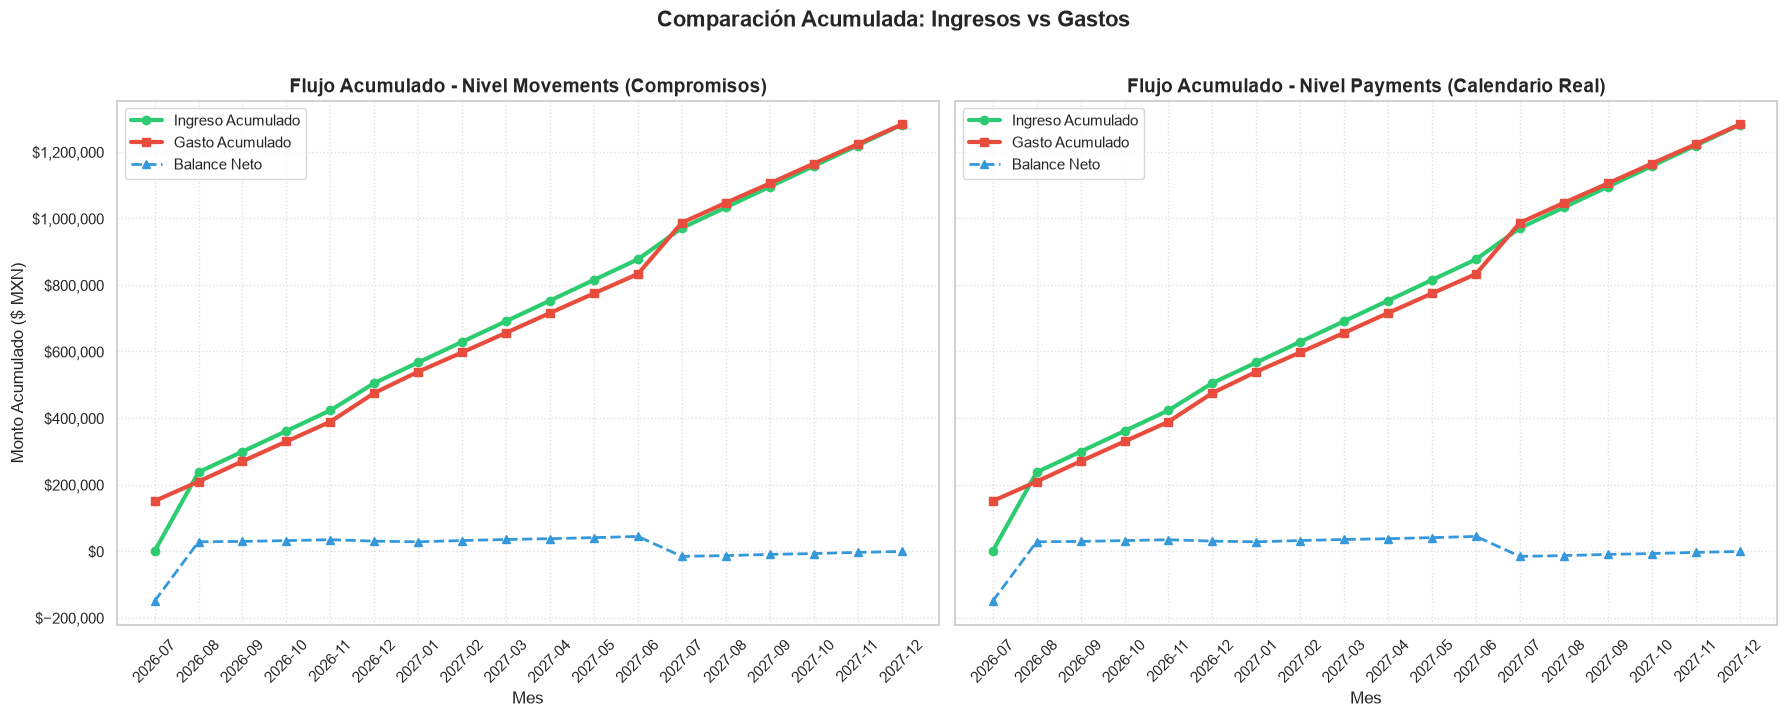

In [5]:
# Función para calcular flujo mensual y acumulado
def calcular_flujo_acumulado(df, col_monto, col_tipo):
    df_agg = df.groupby(['period_month', col_tipo])[col_monto].sum().unstack(fill_value=0).reset_index()
    for col in ['Ingreso', 'Gasto']:
        if col not in df_agg.columns:
            df_agg[col] = 0.0
    df_agg = df_agg.sort_values('period_month').reset_index(drop=True)
    df_agg['Ingreso_Acumulado'] = df_agg['Ingreso'].cumsum()
    df_agg['Gasto_Acumulado'] = df_agg['Gasto'].cumsum()
    df_agg['Balance_Neto_Acumulado'] = df_agg['Ingreso_Acumulado'] - df_agg['Gasto_Acumulado']
    return df_agg

flujo_mov = calcular_flujo_acumulado(df_movements, 'movement_amount', 'movement_type')
flujo_pay = calcular_flujo_acumulado(df_payments, 'payment_amount', 'movement_type')

# Gráfico 2.1: Acumulado Movements vs Payments (Ingreso vs Gasto)
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Movements Subplot
axes[0].plot(flujo_mov['period_month'], flujo_mov['Ingreso_Acumulado'], label='Ingreso Acumulado', color='#2ecc71', lw=3, marker='o')
axes[0].plot(flujo_mov['period_month'], flujo_mov['Gasto_Acumulado'], label='Gasto Acumulado', color='#e74c3c', lw=3, marker='s')
axes[0].plot(flujo_mov['period_month'], flujo_mov['Balance_Neto_Acumulado'], label='Balance Neto', color='#3498db', lw=2, linestyle='--', marker='^')
axes[0].set_title('Flujo Acumulado - Nivel Movements (Compromisos)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Monto Acumulado ($ MXN)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter('${x:,.0f}')
axes[0].legend(loc='upper left', frameon=True)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Payments Subplot
axes[1].plot(flujo_pay['period_month'], flujo_pay['Ingreso_Acumulado'], label='Ingreso Acumulado', color='#2ecc71', lw=3, marker='o')
axes[1].plot(flujo_pay['period_month'], flujo_pay['Gasto_Acumulado'], label='Gasto Acumulado', color='#e74c3c', lw=3, marker='s')
axes[1].plot(flujo_pay['period_month'], flujo_pay['Balance_Neto_Acumulado'], label='Balance Neto', color='#3498db', lw=2, linestyle='--', marker='^')
axes[1].set_title('Flujo Acumulado - Nivel Payments (Calendario Real)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter('${x:,.0f}')
axes[1].legend(loc='upper left', frameon=True)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Comparación Acumulada: Ingresos vs Gastos', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

2026-09-09 14:25:10,320 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-09 14:25:10,323 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-09 14:25:10,327 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-09 14:25:10,329 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-09 14:25:10,344 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or 

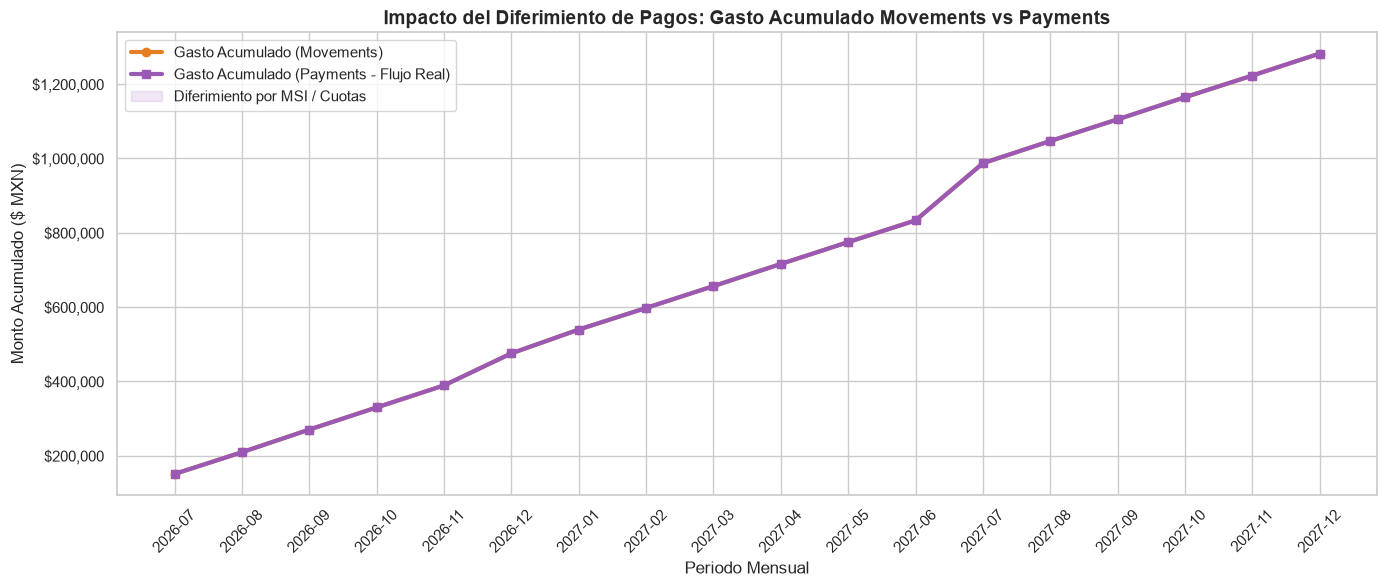

In [6]:
# Gráfico 2.2: Comparación directa de Gasto Acumulado (Movements vs Payments)
plt.figure(figsize=(14, 6))
plt.plot(flujo_mov['period_month'], flujo_mov['Gasto_Acumulado'], label='Gasto Acumulado (Movements)', color='#e67e22', lw=3, marker='o')
plt.plot(flujo_pay['period_month'], flujo_pay['Gasto_Acumulado'], label='Gasto Acumulado (Payments - Flujo Real)', color='#9b59b6', lw=3, marker='s')
plt.fill_between(flujo_pay['period_month'], flujo_mov['Gasto_Acumulado'], flujo_pay['Gasto_Acumulado'], color='#9b59b6', alpha=0.15, label='Diferimiento por MSI / Cuotas')

plt.title('Impacto del Diferimiento de Pagos: Gasto Acumulado Movements vs Payments', fontsize=14, fontweight='bold')
plt.xlabel('Periodo Mensual')
plt.ylabel('Monto Acumulado ($ MXN)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

---
## 🏷️ 3. Análisis de Gastos por Categoría y Método de Pago

Visualizamos la concentración de los gastos por categoría y la distribución según el método de pago utilizado.

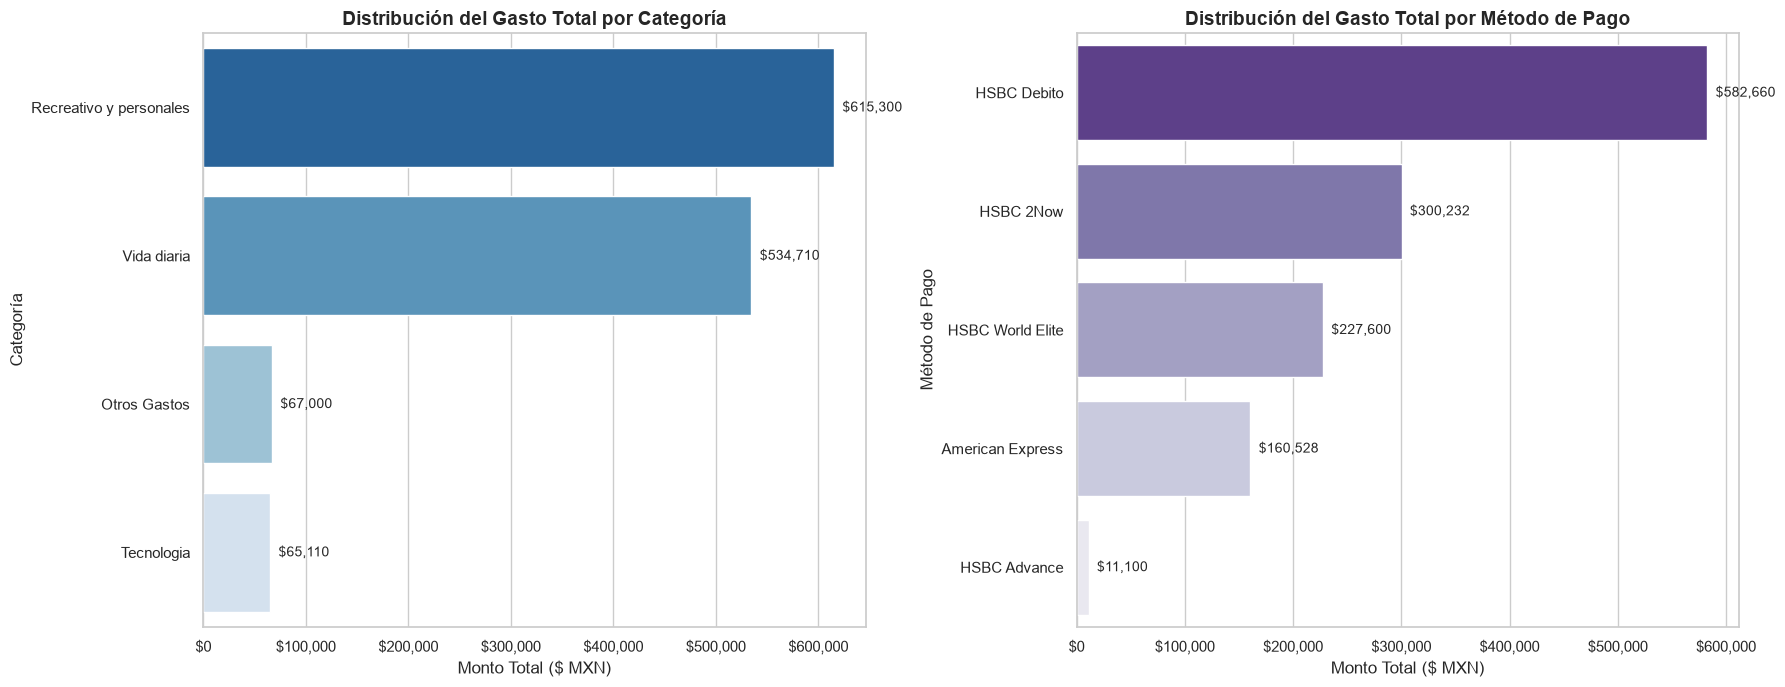

In [7]:
# Preparación de datos de gasto a nivel Payments
gasto_cat = gastos_payments.groupby('category_name')['payment_amount'].sum().sort_values(ascending=False).reset_index()
gasto_pm = gastos_payments.groupby('payment_method_name')['payment_amount'].sum().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 3.1: Gastos por Categoría
sns.barplot(
    data=gasto_cat,
    x='payment_amount',
    y='category_name',
    ax=axes[0],
    palette='Blues_r'
)
axes[0].set_title('Distribución del Gasto Total por Categoría', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Monto Total ($ MXN)')
axes[0].set_ylabel('Categoría')
axes[0].xaxis.set_major_formatter('${x:,.0f}')
for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(f'${width:,.0f}', (width, p.get_y() + p.get_height() / 2.),
                     xytext=(6, 0), textcoords='offset points', ha='left', va='center', fontsize=10)

# Gráfico 3.2: Gastos por Método de Pago
sns.barplot(
    data=gasto_pm,
    x='payment_amount',
    y='payment_method_name',
    ax=axes[1],
    palette='Purples_r'
)
axes[1].set_title('Distribución del Gasto Total por Método de Pago', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Monto Total ($ MXN)')
axes[1].set_ylabel('Método de Pago')
axes[1].xaxis.set_major_formatter('${x:,.0f}')
for p in axes[1].patches:
    width = p.get_width()
    axes[1].annotate(f'${width:,.0f}', (width, p.get_y() + p.get_height() / 2.),
                     xytext=(6, 0), textcoords='offset points', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

TypeError: Image data of dtype object cannot be converted to float

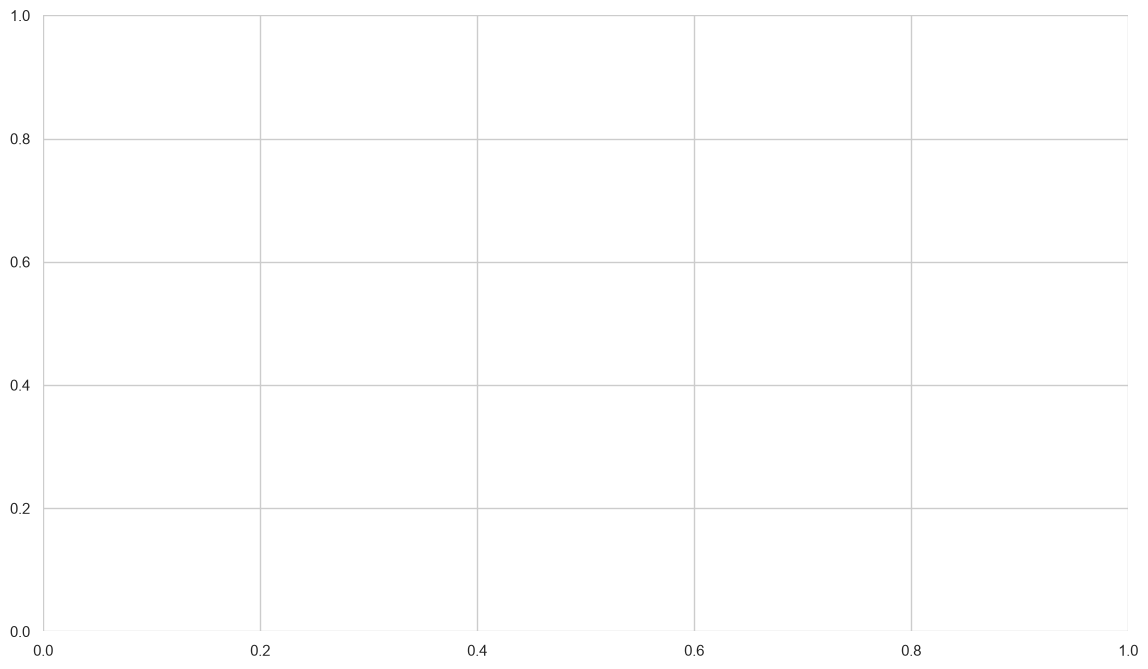

In [8]:
# Gráfico 3.3: Heatmap Cruzado Categoría vs Método de Pago
pivot_cat_pm = pd.pivot_table(
    gastos_payments,
    values='payment_amount',
    index='category_name',
    columns='payment_method_name',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_cat_pm,
    annot=True,
    fmt=',.0f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Monto Gastado ($ MXN)'},
    linewidths=0.8,
    linecolor='white'
)
plt.title('Matriz de Gasto: Categoría vs Método de Pago ($ MXN)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Método de Pago', fontsize=12, labelpad=10)
plt.ylabel('Categoría', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()